In [21]:
!pip install onnxruntime -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 49.5 MB/s eta 0:00:00


In [18]:
!pip install onnxscript -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 15.6 MB/s eta 0:00:00


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
DATA_DIR = '/content/drive/MyDrive/chest_xray'

print('Train NORMAL:', len(os.listdir(os.path.join(DATA_DIR, 'train', 'NORMAL'))))
print('Train PNEUMONIA:', len(os.listdir(os.path.join(DATA_DIR, 'train', 'PNEUMONIA'))))
print('Test NORMAL:', len(os.listdir(os.path.join(DATA_DIR, 'test', 'NORMAL'))))
print('Test PNEUMONIA:', len(os.listdir(os.path.join(DATA_DIR, 'test', 'PNEUMONIA'))))

Train NORMAL: 1342
Train PNEUMONIA: 3876
Test NORMAL: 234
Test PNEUMONIA: 390


In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])


In [4]:
test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])


In [5]:
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), transform=train_transforms)
val_dataset   = datasets.ImageFolder(os.path.join(DATA_DIR, 'val'),   transform=test_transforms)
test_dataset  = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'),  transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [6]:
class_names = train_dataset.classes
print('Classes:', class_names)
print('Class index map:', train_dataset.class_to_idx)
print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

Classes: ['NORMAL', 'PNEUMONIA']
Class index map: {'NORMAL': 0, 'PNEUMONIA': 1}
Train: 5216 | Val: 16 | Test: 624


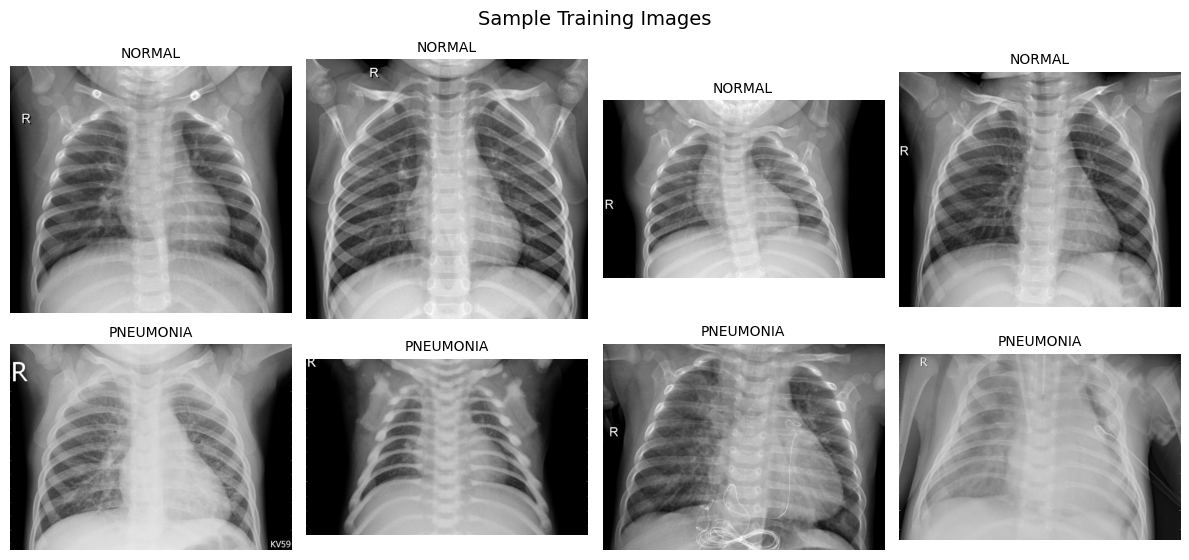

In [7]:
def imshow(img, title=''):
    img = img * 0.5 + 0.5
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(title)
    plt.axis('off')

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('Sample Training Images', fontsize=14)

from PIL import Image

for idx, class_name in enumerate(['NORMAL', 'PNEUMONIA']):
    class_dir = os.path.join(DATA_DIR, 'train', class_name)
    files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:4]
    for col, fname in enumerate(files):
        img_path = os.path.join(class_dir, fname)
        img = Image.open(img_path).convert('L')
        axes[idx, col].imshow(img, cmap='gray')
        axes[idx, col].set_title(class_name, fontsize=10)
        axes[idx, col].axis('off')

plt.tight_layout()
plt.show()

In [8]:
class ChestXRayCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(ChestXRayCNN, self).__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.conv_block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)
        x = self.global_avg_pool(x)
        x = self.classifier(x)
        return x

model = ChestXRayCNN(num_classes=2).to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')


ChestXRayCNN(
  (conv_block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block4): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [9]:
class_weights = torch.tensor([3.0, 1.0]).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

print('Criterion:', criterion)
print('Optimizer:', optimizer)

Criterion: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)


In [10]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

In [11]:
def eval_epoch(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

In [12]:
NUM_EPOCHS = 15
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = eval_epoch(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_chest_xray_model.pth')

    print(f'Epoch [{epoch+1:02d}/{NUM_EPOCHS}] '
          f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

print(f'\nBest Val Accuracy: {best_val_acc:.4f}')

Epoch [01/15] Train Loss: 0.3981 | Train Acc: 0.8252 | Val Loss: 1.7085 | Val Acc: 0.6250
Epoch [02/15] Train Loss: 0.2771 | Train Acc: 0.8888 | Val Loss: 3.0975 | Val Acc: 0.6250
Epoch [03/15] Train Loss: 0.2318 | Train Acc: 0.9039 | Val Loss: 0.3194 | Val Acc: 0.8750
Epoch [04/15] Train Loss: 0.2028 | Train Acc: 0.9206 | Val Loss: 0.9128 | Val Acc: 0.7500
Epoch [05/15] Train Loss: 0.1822 | Train Acc: 0.9294 | Val Loss: 0.8966 | Val Acc: 0.7500
Epoch [06/15] Train Loss: 0.1687 | Train Acc: 0.9342 | Val Loss: 1.0428 | Val Acc: 0.7500
Epoch [07/15] Train Loss: 0.1568 | Train Acc: 0.9411 | Val Loss: 1.9277 | Val Acc: 0.5625
Epoch [08/15] Train Loss: 0.1425 | Train Acc: 0.9494 | Val Loss: 1.4384 | Val Acc: 0.6250
Epoch [09/15] Train Loss: 0.1390 | Train Acc: 0.9475 | Val Loss: 1.5825 | Val Acc: 0.5625
Epoch [10/15] Train Loss: 0.1351 | Train Acc: 0.9528 | Val Loss: 0.7433 | Val Acc: 0.8125
Epoch [11/15] Train Loss: 0.1318 | Train Acc: 0.9511 | Val Loss: 1.2645 | Val Acc: 0.6875
Epoch [12/

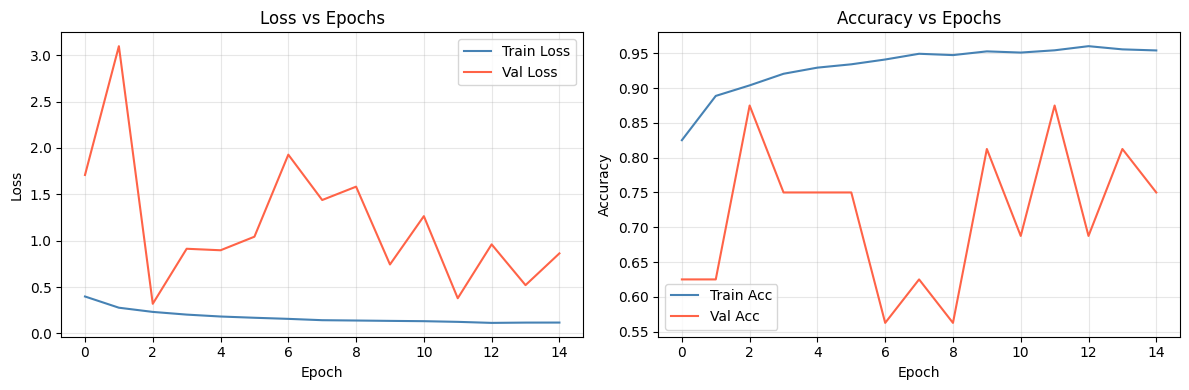

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train Loss', color='steelblue')
ax1.plot(history['val_loss'],   label='Val Loss',   color='tomato')
ax1.set_title('Loss vs Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], label='Train Acc', color='steelblue')
ax2.plot(history['val_acc'],   label='Val Acc',   color='tomato')
ax2.set_title('Accuracy vs Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.load_state_dict(torch.load('best_chest_xray_model.pth', map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print('Classification Report:')
print(classification_report(all_labels, all_preds, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.71      0.88      0.78       234
   PNEUMONIA       0.91      0.78      0.84       390

    accuracy                           0.82       624
   macro avg       0.81      0.83      0.81       624
weighted avg       0.84      0.82      0.82       624



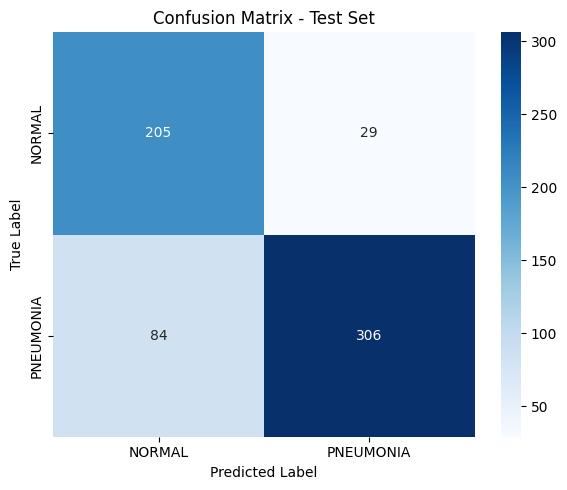

In [15]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [19]:
import torch.onnx
model.load_state_dict(torch.load('best_chest_xray_model.pth', map_location='cpu'))
model.eval().cpu().float()

dummy_input = torch.randn(1, 1, 224, 224, dtype=torch.float32)

os.makedirs('ONNXmodels', exist_ok=True)

torch.onnx.export(
    model,
    dummy_input,
    'ONNXmodels/chest_xray_model.onnx',
    input_names=['input1'],
    output_names=['output1'],
    opset_version=15,
    do_constant_folding=True,
    dynamic_axes={
        'input1':  {0: 'batch'},
        'output1': {0: 'batch'}
    }
)

print('ONNX model saved to ONNXmodels/chest_xray_model.onnx')

/tmp/ipykernel_17209/2675581765.py:9: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0408 00:46:42.128000 17209 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 15 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0408 00:46:43.816000 17209 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1,

[torch.onnx] Obtain model graph for `ChestXRayCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ChestXRayCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 5 of general pattern rewrite rules.
ONNX model saved to ONNXmodels/chest_xray_model.onnx


In [22]:
import onnx
import onnxruntime as ort

onnx_model = onnx.load('ONNXmodels/chest_xray_model.onnx')
onnx.checker.check_model(onnx_model)
print('ONNX model is valid!')

ONNX model is valid!


In [23]:
ort_session = ort.InferenceSession('ONNXmodels/chest_xray_model.onnx')
test_input = np.random.randn(1, 1, 224, 224).astype(np.float32)
ort_outputs = ort_session.run(['output1'], {'input1': test_input})

print('ONNX output shape:', ort_outputs[0].shape)
print('ONNX raw logits:', ort_outputs[0])

ONNX output shape: (1, 2)
ONNX raw logits: [[-23.44043   22.746925]]


In [24]:
with torch.no_grad():
    pt_out = model(torch.tensor(test_input)).numpy()

print('Max diff PyTorch vs ONNX:', np.max(np.abs(pt_out - ort_outputs[0])))
print('Outputs match!' if np.allclose(pt_out, ort_outputs[0], atol=1e-5) else 'WARNING: mismatch!')

Max diff PyTorch vs ONNX: 1.335144e-05
Outputs match!
